In [3]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt

In [5]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
#AU = 1.496e13
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


In [ ]:
def B_lambda(lam, T):
    """
    Planck function in wavelength (erg s^-1 cm^-2 Hz^-1 sr^-1)
    lam: wavelength in cm
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    return (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


def calculate_disk_properties_Andrews(M_star = 1, Mp = 1, Mdot = 1e-5, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 195, 
                            mode="b", lam_mm=1.3e-1, 
                            T_ISM=10.0, Lplanet=1e-5, Lstar = 1.0,  mu=2.3, spec_flux  = None , show_results = False, Rout=None):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)

    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/yr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (Rjup)
    Rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    lam_mm : float
        Wavelength (mm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    mu : float
        Mean molecular weight

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # Turn input values to cgs
    # Disk parameters
    M_star = M_star * M_sun
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / sec_per_yr
    Rin = Rin * R_jup
    rp = rp * AU

    # Turn the luminosites to erg/s
    Lplanet = Lplanet * L_sun
    Lstar = Lstar * L_sun
    
    # 1. Create radial grid between Rin and Rout

    

    if Rout is None:
        Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)
    else:
        Rout = Rout * AU  # assume input Rout is in AU


    R = np.geomspace(Rin, Rout, 100)  # cm
    
    # 2. Calculate T_ext(R)
    #if mode == "b":
    #    L_irr = G * Mp * Mdot / (2.0 * R_p)
    #elif mode == "no_b":
    #    L_irr = 0.0
    #elif mode == "planet":
    #    L_irr = Lplanet
    #else:
    #    raise ValueError("mode must be 'b', 'no_b', or 'planet'")

    L_irr = G * Mp * Mdot / (2.0 * R_p)   # accretion luminosity
    
    #T_irr = 0.0 if L_irr == 0.0 else 
    
    T_irr = (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    
    #print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

    # Planet irradiation

    T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame

    # Star irradiation

    phi_flare = 0.02   # flaring angle of the host disk   (Huang et al. (2018b))

    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # K

    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25  # K
    # T_ext = (T_irr**4 + T_ISM**4)**0.25  # K
    
    # 3. Calculate T_eff(R)
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * 
            (1.0 - np.sqrt(Rin / R)))**0.25  # K
    
    # 4. Calculate Sigma(R)
    Rgas = 8.314e7  # erg/(mol K)
    
    # Sigma prescription 6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    
    # Sigma prescription 7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2
    
    # Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)
    
    # 5. Calculate T_c(R)
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rin / R))
    T_c = (A * f + T_ext**4)**0.25
    
    # 6. Calculate T_b(R)
    # Convert to arrays for consistent handling
    Sigma = np.asarray(Sigma, dtype=float)
    T_c = np.asarray(T_c, dtype=float)
    Teff = np.asarray(Teff, dtype=float)
    T_ext = np.asarray(T_ext, dtype=float)
    
    if not (Sigma.shape == T_c.shape == Teff.shape == T_ext.shape):
        raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")
    
    kappa_mm = 0.034*(0.87/lam_mm) 
    
    # τ_mm = 0.5 κ_mm Σ
    tau_mm = 0.5 * kappa_mm * Sigma
    
    # thin branch: Tb = 2 τ Tc
    Tb_thin = 2.0 * tau_mm * T_c
    
    # thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25
    
    # hard switch at τ=0.5
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    
    # 7. Calculate Tb_avg over the disc
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    num = np.sum(Tbmid * 2 * np.pi * Rmid * dR)
    den = np.pi * (Rout**2 - Rin**2)
    Tb_avg = num / den
    
    # 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area
    I_RJ = 2.0 * kB * Tb / (lam_mm*0.1)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
    F_nu = I_RJ  #np.pi  # erg s^-1 cm^-2 Hz^-1
    
    # Convert distance to cm and calculate flux
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm
    
    # Total emission from disk (before distance scaling)
    F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)   # erg s^-1 Hz^-1 (like Lν)

    # Observed flux at Earth (now include distance scaling)
    F_nu_obs = F_nu_tot / d_cm**2   # erg s^-1 cm^-2 Hz^-1

    # Convert to microJy just for reporting
    F_microJy = F_nu_obs / 1e-29    # µJy

    # In terms of dust mass (use observed flux!)
    #M_dust = (F_nu_obs * d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))

    M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g
    M_dust = M_dust / 5.972e27   # Earth masses

    if spec_flux is not None:
        M_dust_source = spec_flux*1e-29* (d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))
        M_dust_source = M_dust_source / 5.972e27   # earth mass
        print(f'M_dust_source = {M_dust_source} M_earth')
    
    if show_results:
        print(f'Rout = {Rout/AU:.2f} au')
        print(f'Tb_avg = {Tb_avg:.1f} K')
        print(f'F_nu_tot = {F_microJy:.2f} microJy')
    
    
    return {
        'R': R,
        'Rout': Rout / AU,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Teff': Teff,
        'T_c': T_c,
        'Tb': Tb,
        'Sigma': Sigma,
        'tau_mm': tau_mm,
        'F_nu_tot': F_microJy,
        'Tb_avg': Tb_avg,
        'M_dust': M_dust,
        'T_irr': T_irr,
        'T_irr_p': T_irr_p,
        'T_irr_star': T_irr_star
    }




### Check model consistency with Andrews HD143006

Measure the flux limit at the innergap of the disk and try to obtain the same planet properties. Relevant to table 3 and table 4  - try to reproduce table 4.
since the observation is made in different wavelengths, I will take the flux he measured at the wavelength and the location of the gap, plug into my model to plot the radius versus planet mass for D22 and D51 gap. 

1. Change the gap location unit from mas to au (au = mas *dc/1000)
2. Makesure flux is in value of microJy (take the range of flux values for each recovery fraction to verify as it would make it more convenient for me if I want to do CPD injection recovery too) 
3. Plot them


*Note: the observing frequency is 240 GHz which is 1.25 mm , the wavelength-dependent opacity is 2.4 cm^2/g*


Okay , so the situation now is that , the contour levels should be changed into recovery fractions (if present) or sigma levels , the one overlaying line should be the ALMA angular resolution,  representing the locus of CPD parameters where the CPD angular size equals the beam: theta_cpd = Rcpd/d = theta_ALMA, therefore y axis (Rcpd/RHill) = theta_beam*d/RHill , where RHill depends on Mp. so thats the contour line that shows below which the CPD is unresolved. 
without the recovery fractions...what is the minimum flux? should I keep the whole recovery fraction relevant relation as an if case? 




In [48]:




def zhu_plots_flux_map(target_flux_arr, disk_arr=None, rp=165, lam_mm=1.25, alpha=1e-3, plotmass=True , color = '5sigsource', y_max = 0.8, y_min= 0.05):
    """
    Make a DSHARP-style 2D flux map: 
    - x-axis: log10(Mp/Mjup)
    - y-axis: Rcpd / RHill -> normalised disk outer radius
    - shading: log10(Fnu [µJy]) or log10(M_dust [M_earth])
    - contours: recovery flux thresholds

    Parameters
    ----------
    target_flux_arr : list
        Flux thresholds (µJy) for contour level.
    disk_arr : list
        [disk_name, M_star (Msun), distance (pc), Lstar (Lsun)]
    rp : float
        Planet orbital radius (AU).
    lam_mm : float
        Observing wavelength in mm.
    alpha : float
        Viscosity parameter.
    """
    if disk_arr is None:
        disk_arr = ["Unknown", 1.0, 100, 1.0]

    # Grids
    Mp_grid = np.logspace(-2, 1, 80)       # 0.01 - 10 Mjup
    Rout_frac_grid = np.linspace(y_min, y_max, 60)  # fraction of RH   -> w
    M_star_jup = disk_arr[1] * 1047.56     # convert Msun to Mjup for explicit RHill calc

    # Array of flux with 2D shape ( Rout_frac, Mp)
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_dust = np.zeros((len(Rout_frac_grid), len(Mp_grid)))

    # Compute flux grid , for value combination in Rout and MP
    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):
            RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
            print(f'Calculating for Mp = {Mp:.3f} Mjup, Rout_frac = {frac:.3f} -> RHill = {RHill:.2f} au')
            Rout = frac * RHill
            out = calculate_disk_properties(
                M_star=disk_arr[1], Mp=Mp, Mdot=1e-6, alpha=alpha,  # pick fiducial Mdot
                kappaR=2.4, Rin=1, rp=rp, d_pc=disk_arr[2],
                mode="b", lam_mm=lam_mm, T_ISM=10.0, Lplanet=1e-5,
                Lstar=disk_arr[3], mu=2.3, Rout=Rout
            )
            Flux_vals[i, j] = out['F_nu_tot']
            # Mcpd in Jupiter mass
            M_dust[i,j] = out['M_dust'] / 317.8  # convert Earth mass to Jupiter mass

    # Mask out flux values below the minimum target flux (or 1 sigma level )
    min_flux = min(target_flux_arr) # µJy
    masked_Flux_vals = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    masked_M_dust = np.where(Flux_vals >= min_flux, M_dust, np.nan)

    sigma_ujy = target_flux_arr[0]  # Base noise level in µJy
    sigma_levels = [1, 2, 3, 5]  # Sigma multiples to show
    flux_levels = [n * sigma_ujy for n in sigma_levels]  # Actual flux thresholds
    
    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # color scheme

    if color == '5sigsource':
        cmap = 'Blues'
    elif color == 'planet':
        cmap = 'Greens'
    elif color == 'external':
        cmap = 'Purples'


    if plotmass:
        vmin = np.nanmin(np.log10(masked_M_dust))
        vmax = np.nanmax(np.log10(masked_M_dust))
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(masked_M_dust),
            levels=np.linspace(vmin, vmax, 7), cmap=cmap, extend='both'
        )  
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm dust}/M_{\rm Jup})$', fontsize=11)
    else:
        # Use linear flux levels for filled contours
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=flux_levels, cmap=cmap, extend='both'
        )
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    cs = ax.contour(
        np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
        levels=flux_levels,
        colors='black', linewidths=1.5, linestyles='dashed', alpha=0.8
    )
    # Label contours with sigma notation
    labels = [f'{n}σ' for n in sigma_levels]
    fmt = {level: label for level, label in zip(flux_levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)
        

    # Overlay ALMA angular resolution limit
    theta_beam = disk_arr[4]  # arcsec
    d_pc = disk_arr[2]
    # For each Mp, calculate the  Rout_frac = theta_beam * d_pc / RHill
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    Rout_frac_beam =  (theta_beam * d_pc)/ (2*RHill_arr)  # this seems to give overestimation ,(theta_beam * d_pc)
    # for each planet mass, or for each Rout give a Mp 
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', linestyle='-', linewidth=2, label='ALMA detection limit')
    print(f'Min Rout_frac for ALMA detection limit: {np.min(Rout_frac_beam):.3f}')


    # Axis labels
    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)

    # Colorbar

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}, κ=2.4 cm²/g")

    plt.tight_layout()
    plt.show()

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.28 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.29 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.31 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.32 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.33 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.34 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 0.35 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 0.36 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 0.37 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 0.38 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 0.40 au
Calculating for Mp = 0.031 Mjup, Rout_frac = 0.050 -> RHill = 0.41 au
Calculating for Mp =

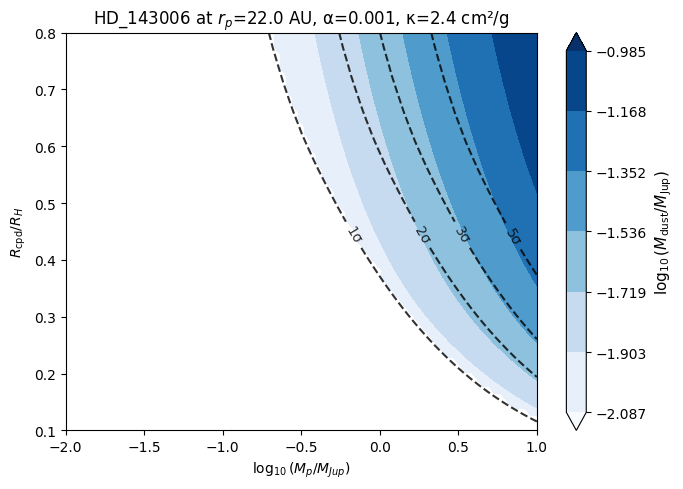

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.65 au
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.67 au
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.69 au
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.71 au
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.73 au
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.75 au
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.77 au
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.79 au
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> RHill = 0.82 au
Calculating for Mp = 0.022 Mjup, Rout_frac = 0.050 -> RHill = 0.84 au
Calculating for Mp = 0.024 Mjup, Rout_frac = 0.050 -> RHill = 0.87 au
Calculating for Mp = 0.026 Mjup, Rout_frac = 0.050 -> RHill = 0.89 au
Calculating for Mp = 0.029 Mjup, Rout_frac = 0.050 -> RHill = 0.92 au
Calculating for Mp = 0.031 Mjup, Rout_frac = 0.050 -> RHill = 0.94 au
Calculating for Mp =

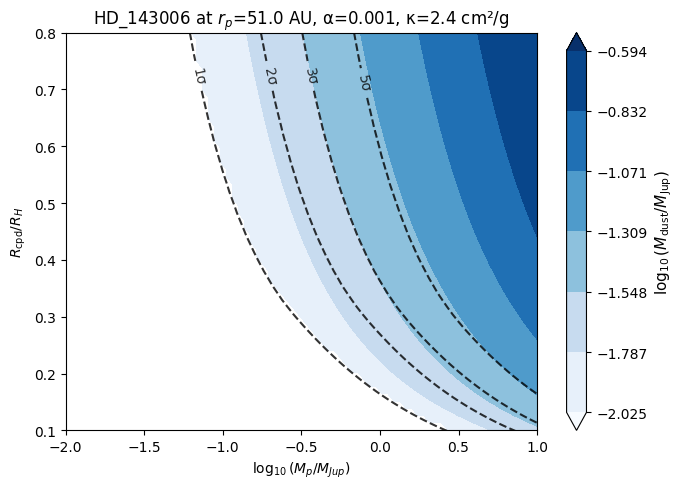

In [42]:
# Gap of HD143006 from Andrews paper
# D22:  103 (mas for r_peak), 
# D51  : 338 (mas for r_peak),

HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]

HD1423006_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

# Run for the D22 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=disk_arr["HD_143006"],
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-3,
    plotmass=True,
)

# Run for the D51 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=disk_arr["HD_143006"],
    rp=rD51,
    lam_mm=1.25,
    alpha=1e-3
)